EDA набора данных о вине (что же ещё, йоу) - https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009/

Сперва подключим библиотеку pandas и выведем: начало, хвост, общую информацию, общую статистику и прочее данных из файла "winequality-red.csv":

In [2]:
import pandas as pd

df = pd.read_csv("winequality-red.csv", sep=',')

df.head(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5


In [13]:
df.tail(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [14]:
df.describe()
df.describe(include='all')

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1598.000000,1598.000000,1599.000000,1594.000000,1597.000000,1599.000000,1597.000000,1598.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.320463,0.527825,0.270976,2.539806,0.087458,15.874922,46.491547,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741328,0.179116,0.194801,1.411312,0.047091,10.460157,32.903240,0.001888,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997837,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [15]:
df[['fixed acidity', 'alcohol', 'quality']].describe()

,fixed acidity,alcohol,quality
count,1598.000000,1599.000000,1599.000000
mean,8.320463,10.422983,5.636023
std,1.741328,1.065668,0.807569
min,4.600000,8.400000,3.000000
25%,7.100000,9.500000,5.000000
50%,7.900000,10.200000,6.000000
75%,9.200000,11.100000,6.000000
max,15.900000,14.900000,8.000000


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1598 non-null   float64
 1   volatile acidity      1598 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1594 non-null   float64
 4   chlorides             1597 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1597 non-null   float64
 7   density               1598 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
df.columns.to_list()

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality']

Вывод df.describe(include='object') с проверкой (так как такого типа данных в моём наборе нету):

In [19]:
object_cols = df.select_dtypes(include='object').columns
category_cols = df.select_dtypes(include='category').columns

if len(object_cols) > 0 :
    df.describe(include='object')
if len(category_cols) > 0 :
    df.describe(include='category')
else:
    print('No objects in dataframe')

No objects in dataframe


In [18]:
df.isnull().sum()

fixed acidity           1
volatile acidity        1
citric acid             0
residual sugar          5
chlorides               2
free sulfur dioxide     0
total sulfur dioxide    2
density                 1
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [44]:
df.duplicated().sum()

np.int64(240)

In [45]:
df[df.duplicated()]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.99660,3.17,0.91,9.5,5
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.99780,3.33,0.83,10.5,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.9,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1563,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1564,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1567,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1581,6.2,0.560,0.09,1.70,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5


In [6]:
df.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

In [7]:
df.shape

(1599, 12)

Уже на этом этапе можно заметить практически идеальность выбранных данных (хотя, конечно, что считать хорошим набором для учёбы, большооой вопрос...): отстутствие текстовых полей - круто, практически полное отсутствие пропусков данных - вообще отлично. Благо, есть выбросы и дубликаты, так что всё же не всё так хорошо, придётся разбираться.

Внесём необходимые правки:

Так как у нас нету объектов типа данных Object или Category, мы можем заполнить пропуски медианой или средним значением. Посмотрим на кол-во выбросов данных и сделаем выбор (если выбросов мало - среднее арифметическое, иначе - медиана).

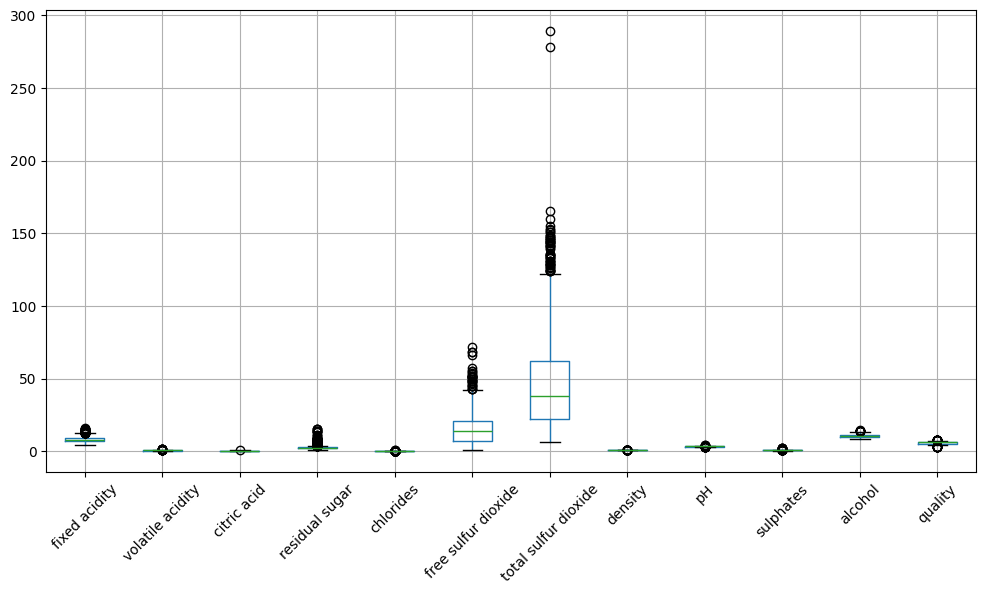

In [25]:
import matplotlib.pyplot as plt
import seaborn as sbn


df.boxplot(figsize=(12, 6))
plt.xticks(rotation=45)
plt.show()

Исходя из построенного графика можно сделать вывод, что так называемых аномальных выбросов в нашем наборе данных не наблюдается, следовательно для заполения пропусков можно использовать среднее арифметическое.
!ВАЖНО переприсвоить значение, чтобы данные о заполнении сохранились. Иначе, как и в случае ниже, используем Inplace=True:

In [ ]:
df.fillna(df.mean(), inplace=True)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [29]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [31]:
df.dropna(axis=0)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [32]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Посчитаем моду:

In [7]:
df['pH'].mode()[0]

np.float64(3.3)

Кажется, правильно подсчитано.
Далее выведем всевозможные перцентили: 5, 25, 50, 75, 95.

In [9]:
percentiles = [0.05, 0.25, 0.50, 0.75, 0.95]
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols].quantile(percentiles)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0.05,6.1,0.27,0.00,1.565,0.0540,4.0,11.0,0.993597,3.06,0.47,9.2,5.0
0.25,7.1,0.39,0.09,1.900,0.0700,7.0,22.0,0.995600,3.21,0.55,9.5,5.0
0.50,7.9,0.52,0.26,2.200,0.0790,14.0,38.0,0.996750,3.31,0.62,10.2,6.0
0.75,9.2,0.64,0.42,2.600,0.0900,21.0,62.0,0.997837,3.40,0.73,11.1,6.0
0.95,11.8,0.84,0.60,5.100,0.1262,35.0,112.2,1.000000,3.57,0.93,12.5,7.0


Кажется, просто смотрим метрики и запоминаем. В целом, всё выглядит адекватно.
Далее рассмотрим дисперсию, асимметрию и эксцесс:

In [19]:
df.select_dtypes(include=['int64', 'float64']).var()

fixed acidity              3.032223
volatile acidity           0.032082
citric acid                0.037947
residual sugar             1.991803
chlorides                  0.002218
free sulfur dioxide      109.414884
total sulfur dioxide    1082.623205
density                    0.000004
pH                         0.023835
sulphates                  0.028733
alcohol                    1.135647
quality                    0.652168
dtype: float64

In [17]:
df.select_dtypes(include=['int64', 'float64']).skew()

fixed acidity           0.981823
volatile acidity        0.671302
citric acid             0.318337
residual sugar          4.539326
chlorides               5.678691
free sulfur dioxide     1.250567
total sulfur dioxide    1.515024
density                 0.070234
pH                      0.193683
sulphates               2.428672
alcohol                 0.860829
quality                 0.217802
dtype: float64

In [18]:
df.select_dtypes(include=['int64', 'float64']).kurtosis()

fixed acidity            1.130461
volatile acidity         1.222837
citric acid             -0.788998
residual sugar          28.579408
chlorides               41.678874
free sulfur dioxide      2.023562
total sulfur dioxide     3.806488
density                  0.933535
pH                       0.806943
sulphates               11.720251
alcohol                  0.200029
quality                  0.296708
dtype: float64

Попробуем объяснить что это значит на примере моих данных:

Дисперсия: некоторые значения очень близки - иные доходят до тысячи. В сущности смысл этого показателя - это сумма того, насколько данное значение отличается от среднего с смысле среднего квадратичного (т.е. x^2-y^2, где x - текущее значение, y - среднее значение). Так что значение в 1000 лишь говорит нам о вероятных выбросах, больших значениях в целом данной колонки. Значения же, близкие к 0, говорят об отстутствии подобного рода событий.

Асимметрия: отклонение пика на графике в сторону. Из положительности всех значений можно сделать вывод, что в целом значения выше среднего арифметического встречаются реже, чем значения ниже среднего арифметического. Значит, вероятнее всего, значения выше ср. арифм. отличаются сильнее от ср. арифм., нежели значения ниже.

Эксцесс: острость графика (в контексте частоты появления определённых значений). Около нуля большинство - значит график нормального распределения достаточно точно описывает эти параметры. Но есть также и скачки (41.6 хлориды). Значит, что пик острее и больше выбросов. 

В дальнейшем убедимся в сделанных выводах (или, наоборот, их опровергнем, построив графики).
А пока разберёмся с преобразованием текстовых признаков в нетекстовые, для этого создадим подобный (в текущем датасете текстовых признаков попросту нет) и применим предложенные преобразования.

In [39]:
df_copy = df.copy()
df_copy['Alcohol power'] = pd.cut(
    df_copy['alcohol'],
    bins=3,
    labels=['low', 'medium', 'high']
)
print(df_copy.columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Alcohol power'],
      dtype='str')


In [40]:
df_encoded = pd.get_dummies(
    df_copy,
    columns=['Alcohol power'],
    dtype=int
)
df_encoded.head(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Alcohol power_low,Alcohol power_medium,Alcohol power_high
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1,0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,0,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1,0,0


In [43]:
label_map = {
    'low': 0,
    'medium': 1, 
    'high': 2,
}
df_copy['alcohol label map'] = df_copy['Alcohol power'].map(label_map)
df_copy.head(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Alcohol power,alcohol label map
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,low,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,low,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,low,0


Я УСТАЛ, А ЗНАЧИТ ГРАФИКИИИИИИ:

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

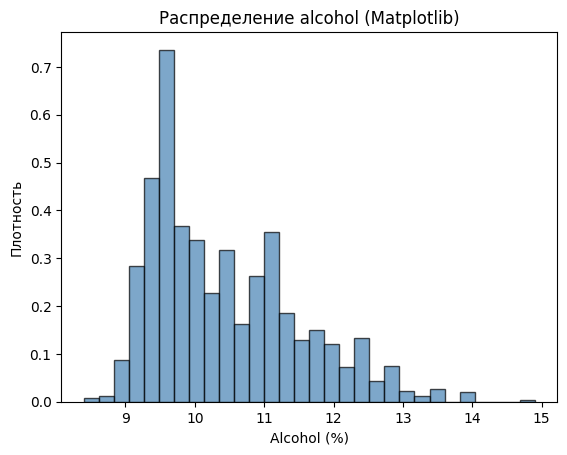

In [20]:
fig, ax = plt.subplots()
ax.hist(df['alcohol'].dropna(), bins=30, density=True, alpha=0.7, color='steelblue', edgecolor='black')
ax.set_title('Распределение alcohol (Matplotlib)')
ax.set_xlabel('Alcohol (%)')
ax.set_ylabel('Плотность')
plt.show()

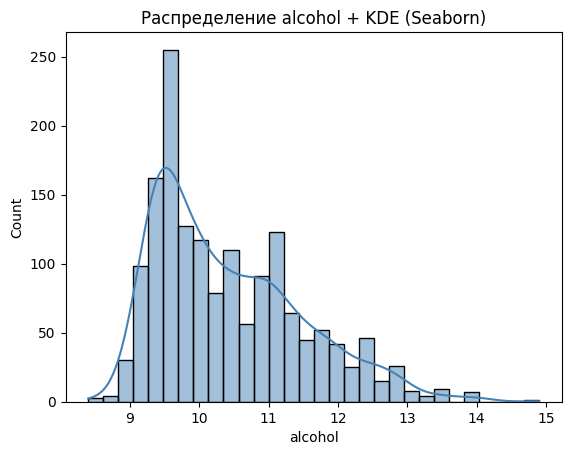

In [21]:
sns.histplot(data=df, x='alcohol', kde=True, bins=30, color='steelblue')
plt.title('Распределение alcohol + KDE (Seaborn)')
plt.show()

In [22]:
fig = px.histogram(df, x='alcohol', nbins=30, marginal='violin', 
                   title='Интерактивное распределение alcohol (Plotly)')
fig.show()

SCATTER PLOT — поиск зависимостей
Зачем: увидеть связь между признаками.

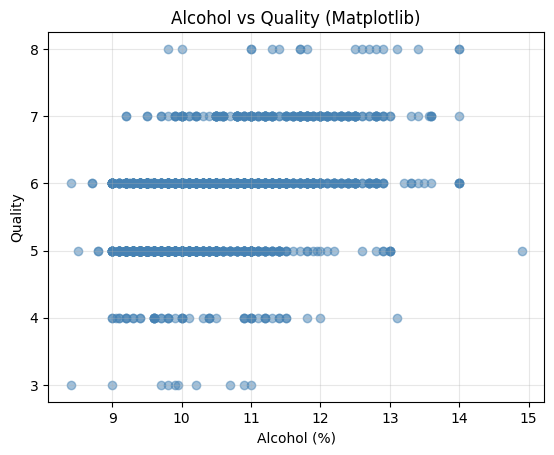

In [23]:
plt.scatter(df['alcohol'], df['quality'], alpha=0.5, c='steelblue')
plt.xlabel('Alcohol (%)')
plt.ylabel('Quality')
plt.title('Alcohol vs Quality (Matplotlib)')
plt.grid(True, alpha=0.3)
plt.show()

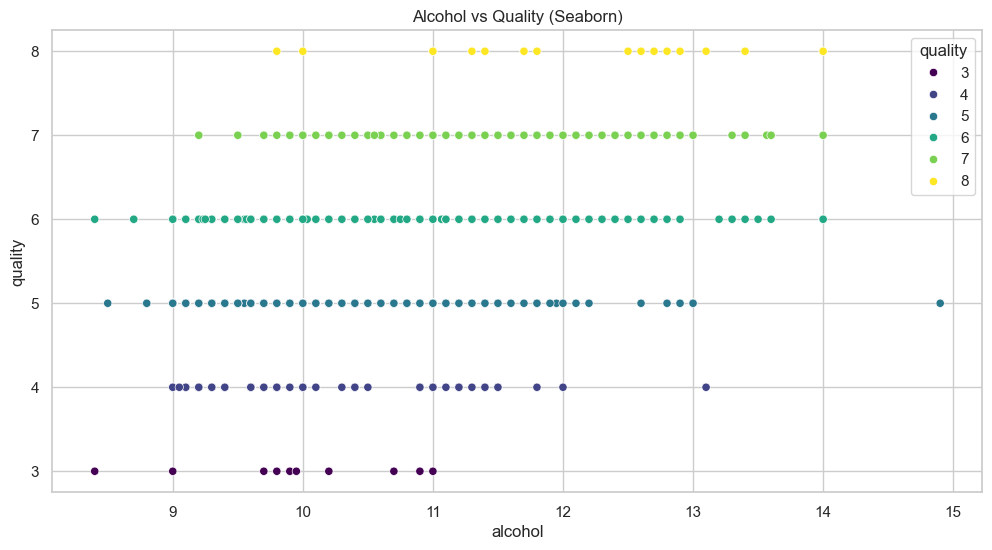

In [4]:
sns.scatterplot(data=df, x='alcohol', y='quality', hue='quality', palette='viridis')
plt.title('Alcohol vs Quality (Seaborn)')
plt.show()

In [25]:
fig = px.scatter(df, x='alcohol', y='quality', color='quality', 
                 hover_data=['pH', 'fixed acidity'],
                 title='Alcohol vs Quality (Plotly)')
fig.show()

BOX PLOT — поиск выбросов
Зачем: найти аномалии и посмотреть разброс.

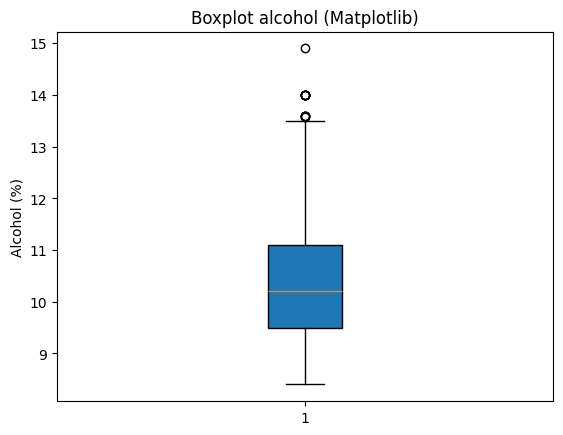

In [26]:
plt.boxplot(df['alcohol'].dropna(), patch_artist=True)
plt.title('Boxplot alcohol (Matplotlib)')
plt.ylabel('Alcohol (%)')
plt.show()

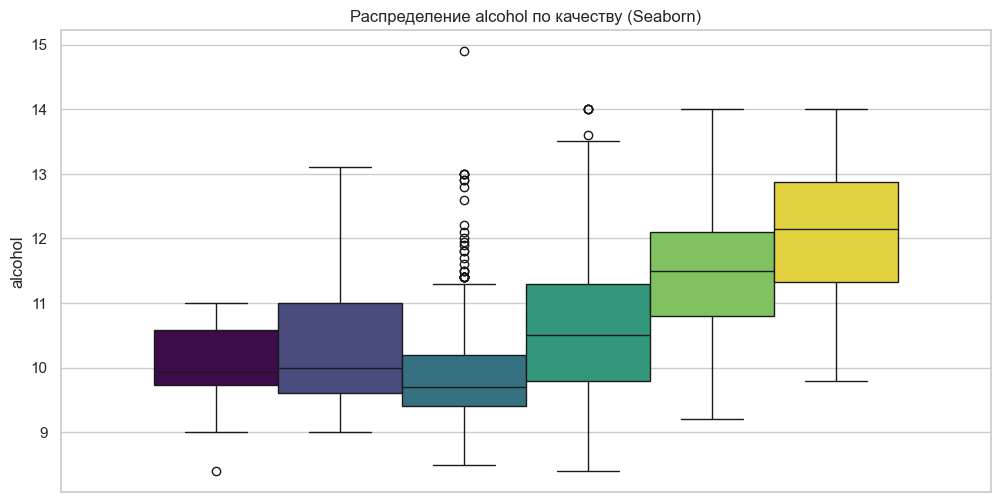

In [5]:
sns.boxplot(data=df, hue='quality', y='alcohol', palette='viridis', legend=False)
plt.title('Распределение alcohol по качеству (Seaborn)')
plt.show()

In [28]:
fig = px.box(df, x='quality', y='alcohol', color='quality', 
             title='Alcohol по качеству (Plotly)')
fig.show()

COUNT PLOT — для категорий
Зачем: посмотреть частоту категорий (quality).

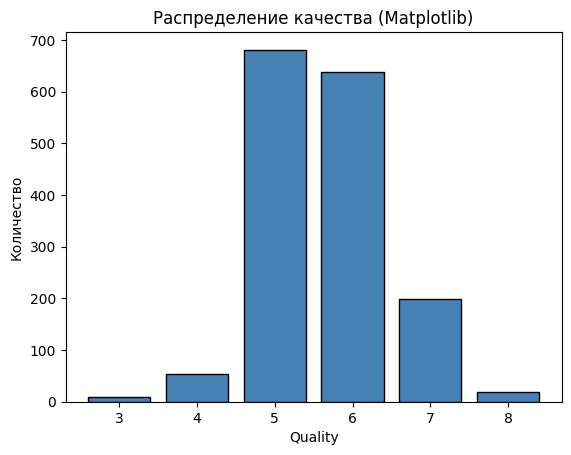

In [29]:
quality_counts = df['quality'].value_counts().sort_index()
plt.bar(quality_counts.index, quality_counts.values, color='steelblue', edgecolor='black')
plt.title('Распределение качества (Matplotlib)')
plt.xlabel('Quality')
plt.ylabel('Количество')
plt.show()

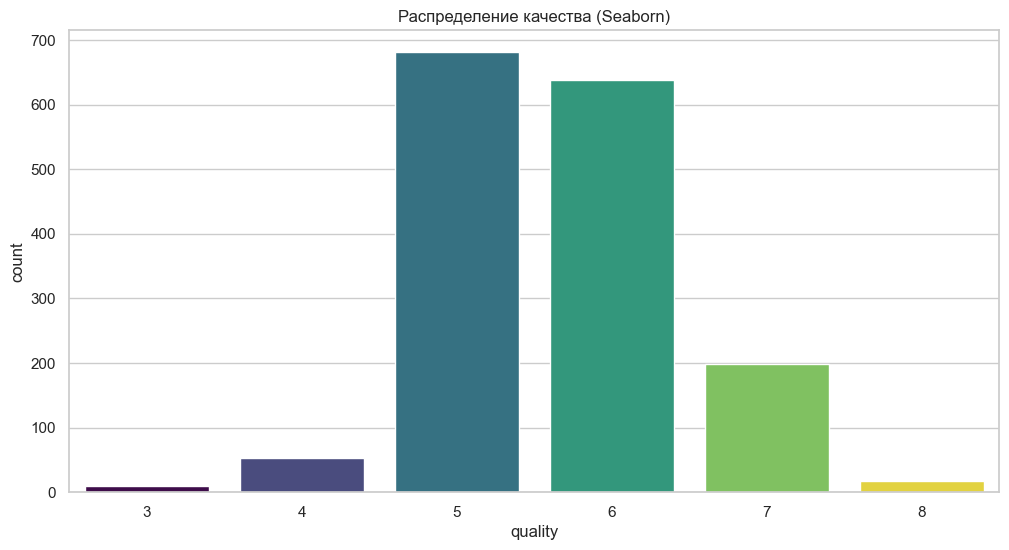

In [8]:
sns.countplot(data=df, x='quality', palette='viridis', hue='quality', legend=False)
plt.title('Распределение качества (Seaborn)')
plt.show()

In [31]:
fig = px.histogram(df, x='quality', title='Распределение качества (Plotly)', text_auto=True)
fig.show()

HEATMAP КОРРЕЛЯЦИЙ + ВЫВОД
Зачем: увидеть, какие признаки связаны.

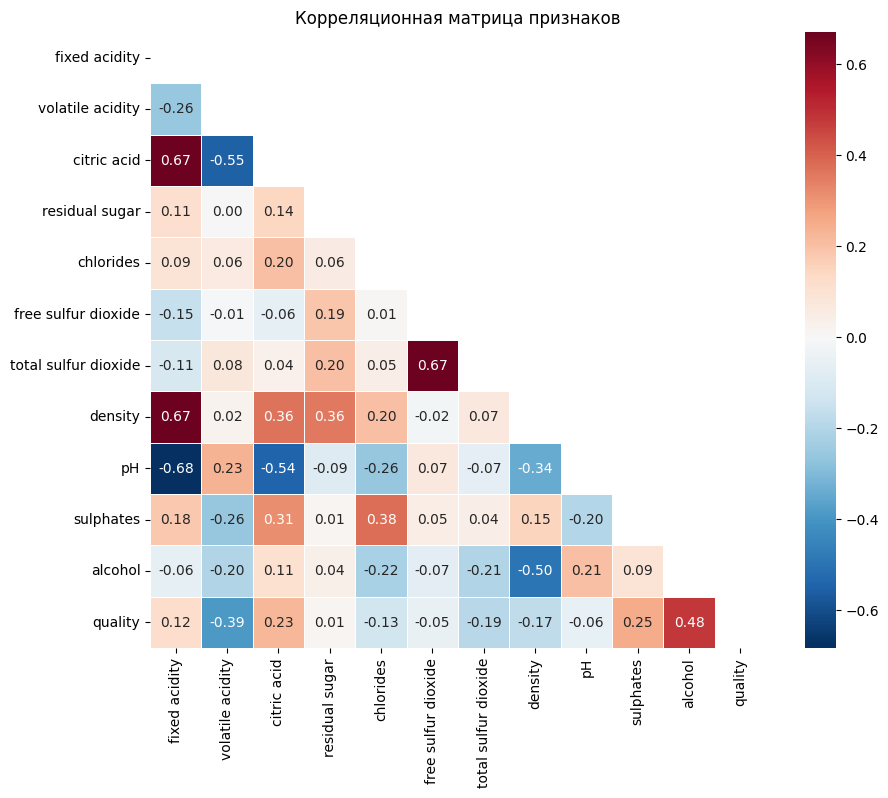

In [32]:
# Корреляционная матрица
corr = df.select_dtypes(include=[np.number]).corr()

# Маска для верхней части
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Корреляционная матрица признаков')
plt.show()

In [33]:
fig = px.imshow(corr, text_auto=True, color_continuous_scale='RdBu_r',
                zmin=-1, zmax=1, title='Корреляционная матрица (Plotly)')
fig.show()

In [35]:
# Корреляции с quality
quality_corr = corr['quality'].sort_values(ascending=False)
print("Корреляции с качеством:")
print(quality_corr.round(3))

print("\nСамые сильные корреляции:")
# Находим пары с |corr| > 0.5
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.5:
            print(f"{corr.columns[i]} — {corr.columns[j]}: {corr.iloc[i, j]:.3f}")

Корреляции с качеством:
quality                 1.000
alcohol                 0.476
sulphates               0.251
citric acid             0.226
fixed acidity           0.124
residual sugar          0.014
free sulfur dioxide    -0.051
pH                     -0.058
chlorides              -0.129
density                -0.175
total sulfur dioxide   -0.186
volatile acidity       -0.391
Name: quality, dtype: float64

Самые сильные корреляции:
fixed acidity — citric acid: 0.672
fixed acidity — density: 0.668
fixed acidity — pH: -0.683
volatile acidity — citric acid: -0.553
citric acid — pH: -0.542
free sulfur dioxide — total sulfur dioxide: 0.668


Выводы (о датасете и не только):
- 1599 строк, 12 колонок
- нету (во всяком случае изначально не было) объектов типа "object" (по сути, текста) в датасете
- отсутствие пропусков (созданы искусственно)
- редки выбросы данных (около 0,05%)
- в целом данные распределены равномерно, что видно как на графиках, так и на выводе эксцентресситета, дисперсии, медианных значений и тд
- можно заключить, что данные изначально подобраны прекрасно

Гипотезы:
- стоит подбирать датасеты с "проблемами" в учебных целях
- вероятнее всего, выбросы могут быть скорелированны некоторым добавочным значением (например, нормой полученного ответа) и, как следствие, быть удалены из базы данных с помощью dropna()
- чаще выбросы есть следствие некачественного подбора данных, реже - закономерный результат, который нужно умело обработать (например, зп). Всё зависит от поставленной задачи.

В следующий раз я бы сделал следующее: взял бы модель "с проблемами", которую нужно будет починить прежде чем работать с ней дальше.

Блок про AI
  он делал всё что только возможно: пояснял основы, рассказывал какие методы вызывать и что получится, как это устроено под капотом и тд.
  наибольший его вклад - это графики. Выводы, гипотезы и булеты писались полностью самостоятельно на основе ранее проделанной работы.